# PQDOS Reliability Analysis

Recovery success rate and repair behaviour, from the benchmark CSV described
in [ADR-0007](../adr/0007-metrics-collector.md).

`REPAIR` records carry `failed_nodes` (the number of missing shards that were
reconstructed) and `success` (whether reconstruction met the `k` threshold).

> **Note:** the default `BenchmarkMain` harness does not fail nodes externally,
> so a real run may contain only successful repairs with `failed_nodes = 0`.
> This notebook degrades gracefully and is ready for richer failure sweeps.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

import metrics_utils as mu

df = mu.load_metrics()
repair = df[df["operation"] == "REPAIR"].copy()
print(f"Loaded {len(df)} records, {len(repair)} REPAIR records")

Loaded 1596 records, 420 REPAIR records


## 1. Overall success rate

Fraction of successful operations, overall and for repairs specifically.

In [2]:
overall = df.groupby("operation")["success"].mean().rename("success_rate")
print(overall.round(4).to_string())

if repair.empty:
    print("\nNo REPAIR records; remaining cells will be skipped.")
else:
    print(f"\nREPAIR success rate: {repair['success'].mean():.4f}")

operation
GET          1.0
PUT          1.0
REPAIR    0.7286

REPAIR success rate: 0.7286


## 2. Recovery success rate by erasure configuration

Higher parity (`m`) should tolerate more failures, so success rate is expected
to be robust as `k+m` grows.

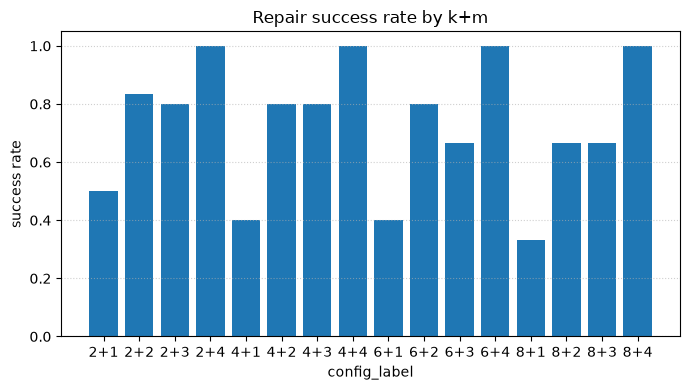

,config_label,success_rate,count
0,2+1,0.5,36
1,2+2,0.833,36
2,2+3,0.8,30
3,2+4,1.0,30
4,4+1,0.4,30
5,4+2,0.8,30
6,4+3,0.8,30
7,4+4,1.0,30
8,6+1,0.4,30
9,6+2,0.8,30


In [3]:
if not repair.empty:
    by_cfg = (
        repair.groupby("config_label")["success"]
        .agg(["mean", "count"])
        .rename(columns={"mean": "success_rate"})
        .reset_index()
    )
    fig, ax = plt.subplots(figsize=(7, 4))
    mu.bar(by_cfg, x="config_label", y="success_rate",
           title="Repair success rate by k+m", ylabel="success rate", ax=ax)
    ax.set_ylim(0, 1.05)
    plt.tight_layout()
    plt.show()
    display(by_cfg.round(3))

## 3. Success rate vs failure ratio

`failure_ratio = failed_nodes / total_nodes`. Reconstruction is expected to
succeed while enough shards remain (`available >= k`).

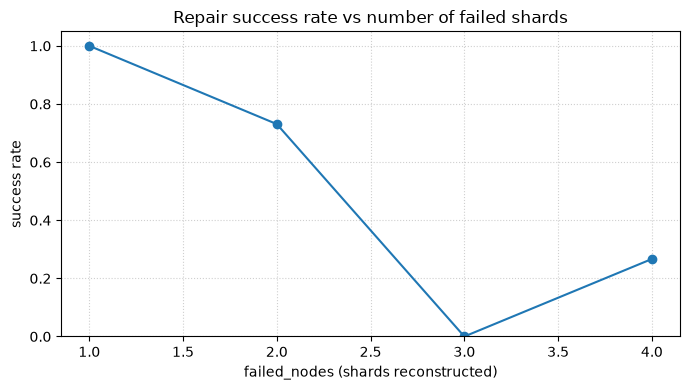

In [4]:
if not repair.empty and repair["failed_nodes"].fillna(0).gt(0).any():
    by_fail = repair.groupby("failed_nodes")["success"].mean()
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(by_fail.index, by_fail.values, marker="o")
    ax.set_xlabel("failed_nodes (shards reconstructed)")
    ax.set_ylabel("success rate")
    ax.set_ylim(0, 1.05)
    ax.set_title("Repair success rate vs number of failed shards")
    ax.grid(True, linestyle=":", alpha=0.6)
    plt.tight_layout()
    plt.show()
else:
    print("No repairs with failed_nodes > 0 - run a failure sweep to populate this view.")

## 4. Repair latency distribution

Cost of reconstruction, and how it scales with the number of shards repaired.

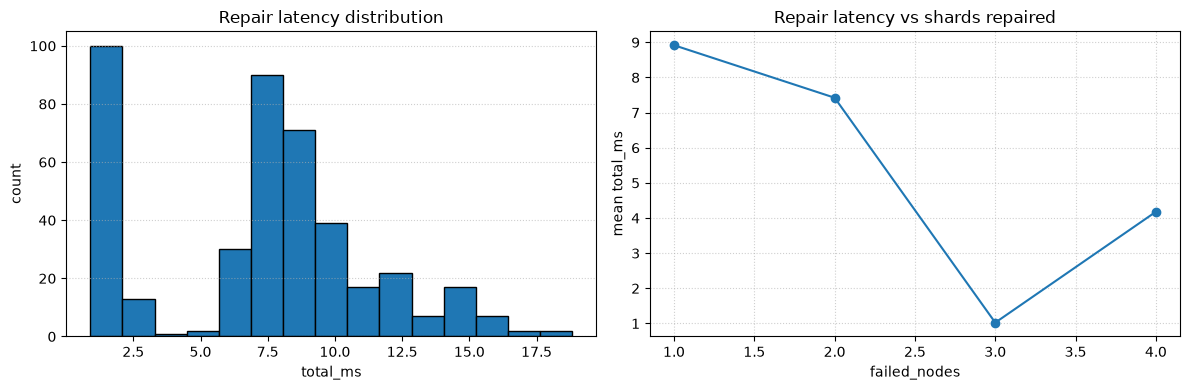

In [5]:
if not repair.empty:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].hist(repair["total_ms"].dropna(), bins=15, edgecolor="black")
    axes[0].set_xlabel("total_ms")
    axes[0].set_ylabel("count")
    axes[0].set_title("Repair latency distribution")
    axes[0].grid(axis="y", linestyle=":", alpha=0.6)

    if repair["failed_nodes"].fillna(0).gt(0).any():
        by_fail = repair.groupby("failed_nodes")["total_ms"].mean()
        axes[1].plot(by_fail.index, by_fail.values, marker="o")
        axes[1].set_xlabel("failed_nodes")
        axes[1].set_ylabel("mean total_ms")
        axes[1].set_title("Repair latency vs shards repaired")
        axes[1].grid(True, linestyle=":", alpha=0.6)
    else:
        axes[1].set_visible(False)

    plt.tight_layout()
    plt.show()

## 5. Summary statistics

In [6]:
if not repair.empty:
    display(mu.summary_by(repair, group_cols=["config_label"],
                          metric_cols=["success", "failed_nodes", "total_ms"]))

success                      failed_nodes                       \
                mean    std min max count         mean    std min max count   
config_label                                                                  
2+1              0.5  0.507   0   1    36        1.667  0.756   1   3    36   
2+2            0.833  0.378   0   1    36        1.833  1.082   1   4    36   
2+3              0.8  0.407   0   1    30          2.0  1.114   1   4    30   
2+4              1.0    0.0   1   1    30          2.0  1.114   1   4    30   
4+1              0.4  0.498   0   1    30          2.0  1.114   1   4    30   
4+2              0.8  0.407   0   1    30          2.0  1.114   1   4    30   
4+3              0.8  0.407   0   1    30          2.0  1.114   1   4    30   
4+4              1.0    0.0   1   1    30          2.0  1.114   1   4    30   
6+1              0.4  0.498   0   1    30          2.0  1.114   1   4    30   
6+2              0.8  0.407   0   1    30          2.0  1.114   1   4    30   
6+3            0.667  0.485   0   1    18        2.333  1.283   1   4    18   
6+4              1.0    0.0   1   1    18        2.333  1.283   1   4    18   
8+1            0.333  0.485   0   1    18        2.333  1.283   1   4    18   
8+2            0.667  0.485   0   1    18        2.333  1.283   1   4    18   
8+3            0.667  0.485   0   1    18        2.333  1.283   1   4    18   
8+4              1.0    0.0   1   1    18        2.333  1.283   1   4    18   

             total_ms                              
                 mean    std    min     max count  
config_label                                       
2+1             4.541  4.069  0.900  15.125    36  
2+2             7.194  3.917  1.060  15.741    36  
2+3             7.452  4.386  1.114  18.262    30  
2+4             9.588  3.460  6.568  18.824    30  
4+1             4.071  3.422  1.074  11.244    30  
4+2             7.272  3.442  1.365  13.543    30  
4+3             7.796  3.830  1.367  16.283    30  
4+4             9.867  2.695  7.136  16.579    30  
6+1             4.280  3.460  1.349  11.784    30  
6+2             7.653  3.368  1.471  12.650    30  
6+3             7.073  4.017  1.589  12.742    18  
6+4            10.405  2.133  8.021  14.910    18  
8+1             4.370  3.612  1.578  12.070    18  
8+2             7.201  4.014  1.744  12.347    18  
8+3             8.344  4.742  1.853  15.060    18  
8+4            11.329  1.928  9.341  15.218    18